In [2]:
# 1. Montar o Google Drive para aceder ao dataset_farmtech
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 2. Clonar o repositório oficial da YOLOv5 e instalar as dependências
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
%pip install -qr requirements.txt

import torch
print(f"Setup concluído. A usar torch {torch.__version__} ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})")

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 17898 (delta 58), reused 22 (delta 22), pack-reused 17822 (from 2)
Receiving objects: 100% (17898/17898), 17.02 MiB | 23.97 MiB/s, done.
Resolving deltas: 100% (12191/12191), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 11.1 MB/s eta 0:00:00
Setup concluído. A usar torch 2.10.0+cpu (CPU)


In [4]:
# 3. Primeiro Experimento: Treino com 30 Épocas
!python train.py --img 416 --batch 16 --epochs 30 --data /content/drive/MyDrive/dataset_farmtech/data.yaml --weights yolov5s.pt --name exp_30_epocas

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/drive/MyDrive/dataset_farmtech/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=416, re

In [5]:
# 4. Segundo Experimento: Treino com 60 Épocas
!python train.py --img 416 --batch 16 --epochs 60 --data /content/drive/MyDrive/dataset_farmtech/data.yaml --weights yolov5s.pt --name exp_60_epocas

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/drive/MyDrive/dataset_farmtech/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=60, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp_60_ep

In [6]:
# 5. Inferência (Teste Prático): Apresentação para o Cliente da FarmTech
!python detect.py --weights runs/train/exp_60_epocas/weights/best.pt --img 416 --conf 0.4 --source /content/drive/MyDrive/dataset_farmtech/images/test --name teste_cliente

detect: weights=['runs/train/exp_60_epocas/weights/best.pt'], source=/content/drive/MyDrive/dataset_farmtech/images/test, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_cliente, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_farmtech/images/test/download (1).jpg: 288x416 1 trator, 179.7ms
image 2/8 /content/drive/MyDrive/dataset_farmtech/images/test/download (2).jpg: 288x416 1 trator, 136.0ms
image 3/8 /content/drive/MyDrive/dataset_farmtech/images/test/download (23).

Apresentação de Resultados - Cliente FarmTech Solutions:


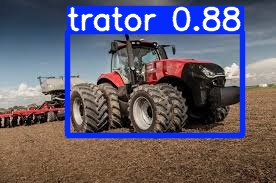

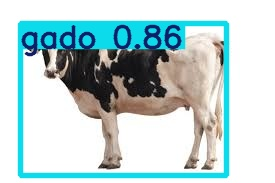

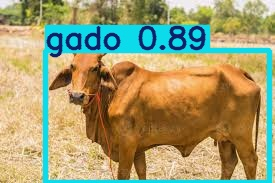

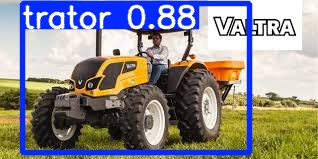

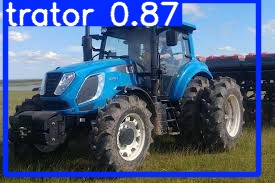

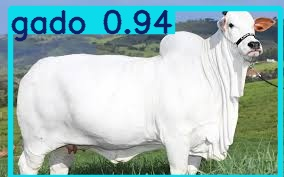

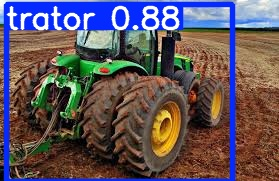

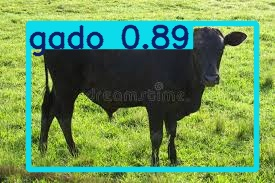

In [17]:
# 6. Exibir as imagens processadas diretamente no Notebook
import glob
from IPython.display import Image, display

print("Apresentação de Resultados - Cliente FarmTech Solutions:")
for img_path in glob.glob('runs/detect/teste_cliente/*.jpg'):
    display(Image(filename=img_path))

Gráficos de Desempenho - Treino Curto (30 Épocas):


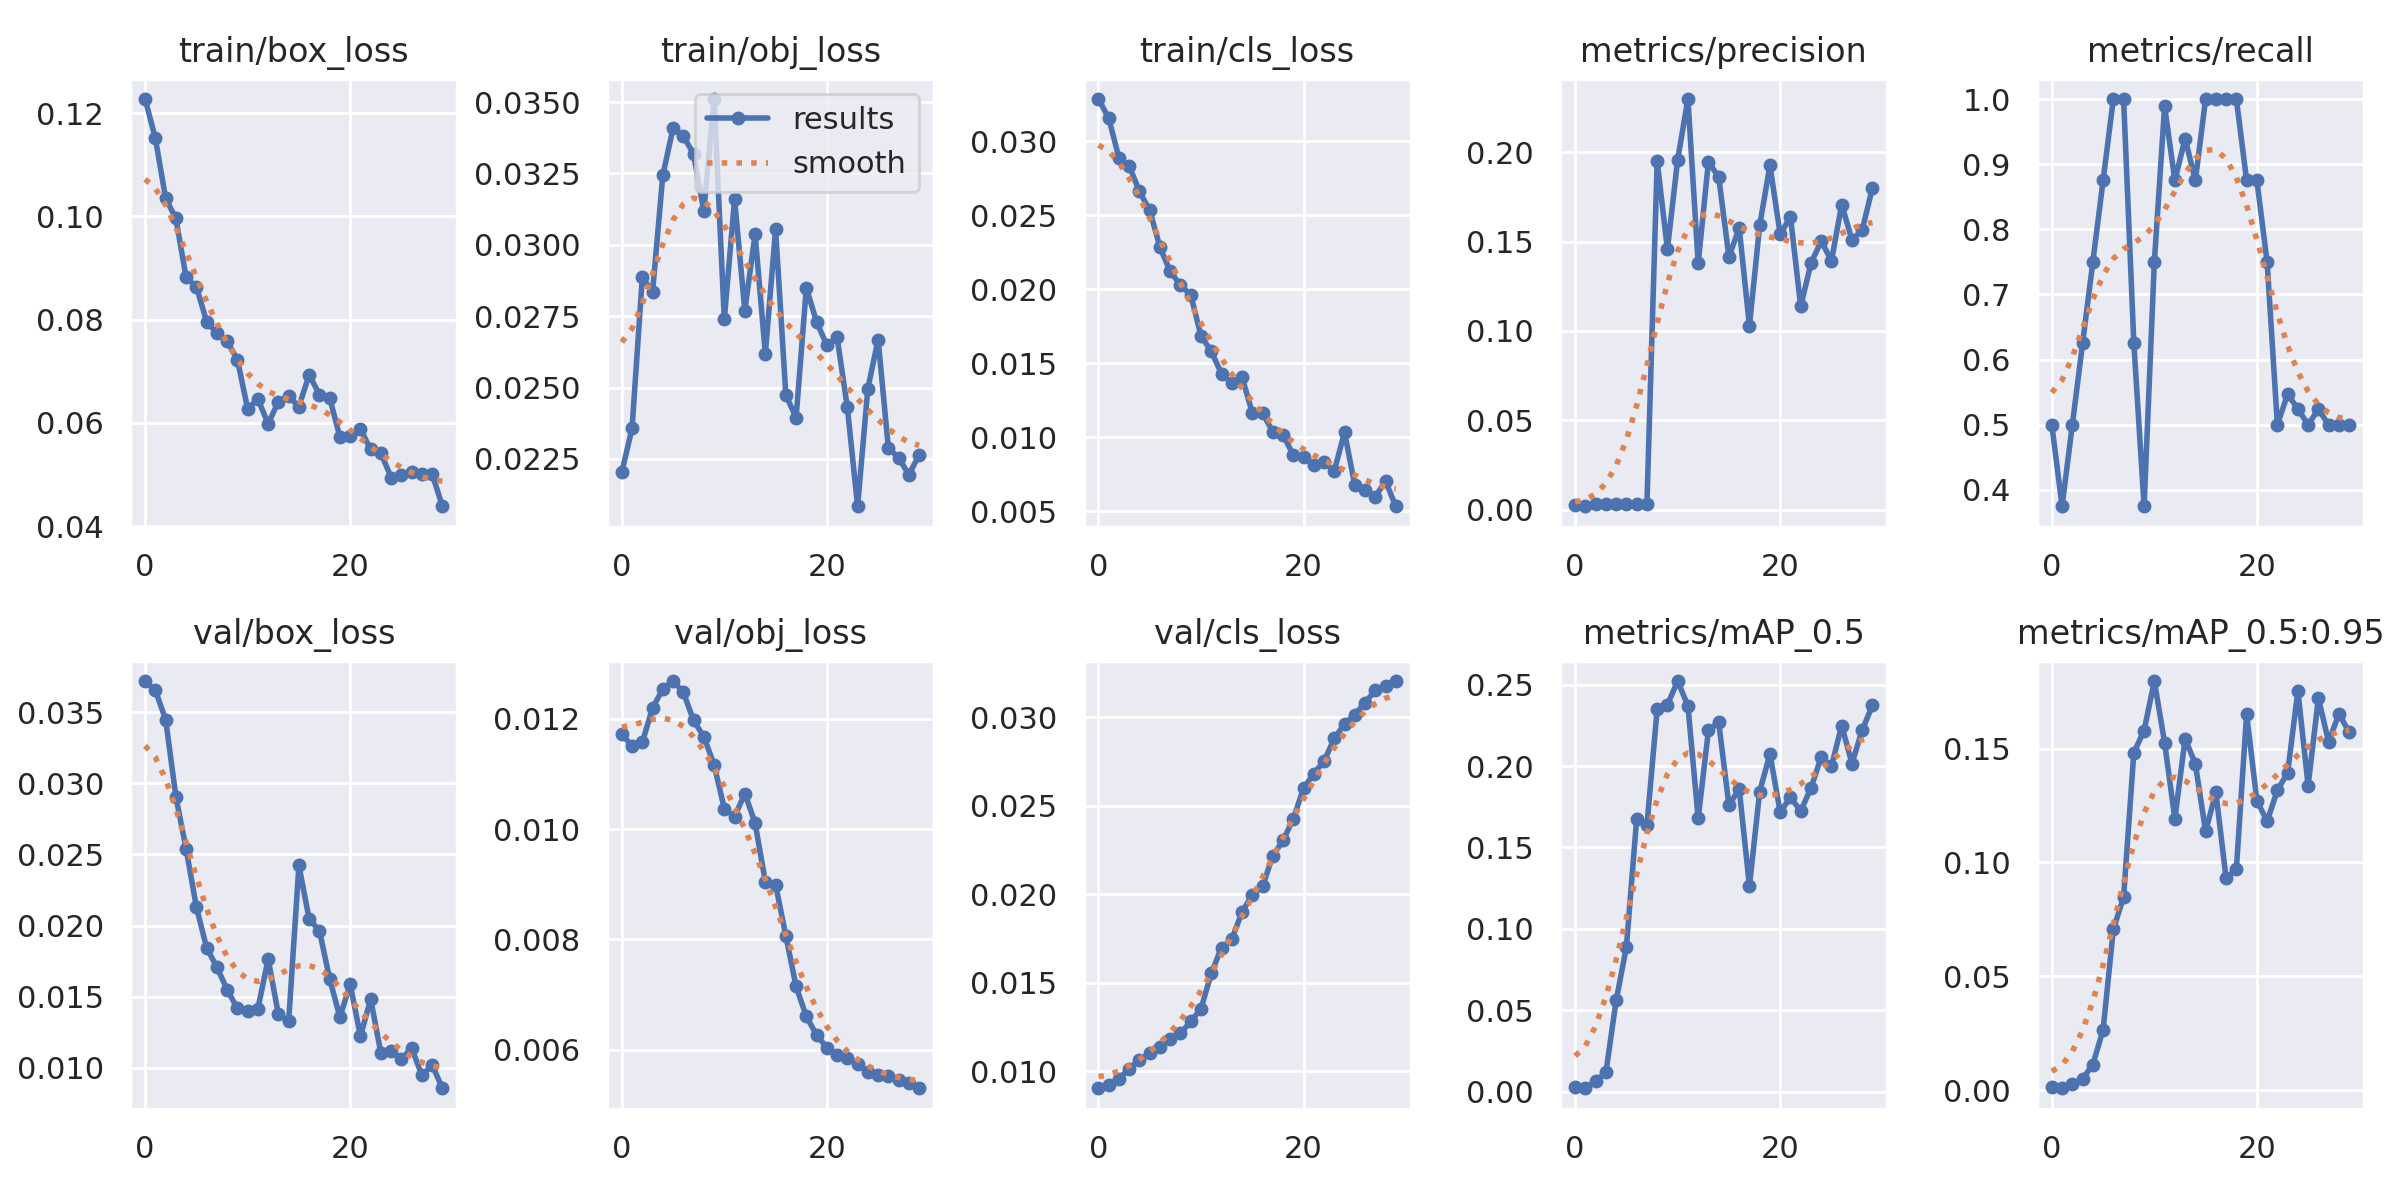


Gráficos de Desempenho - Treino Longo (60 Épocas):


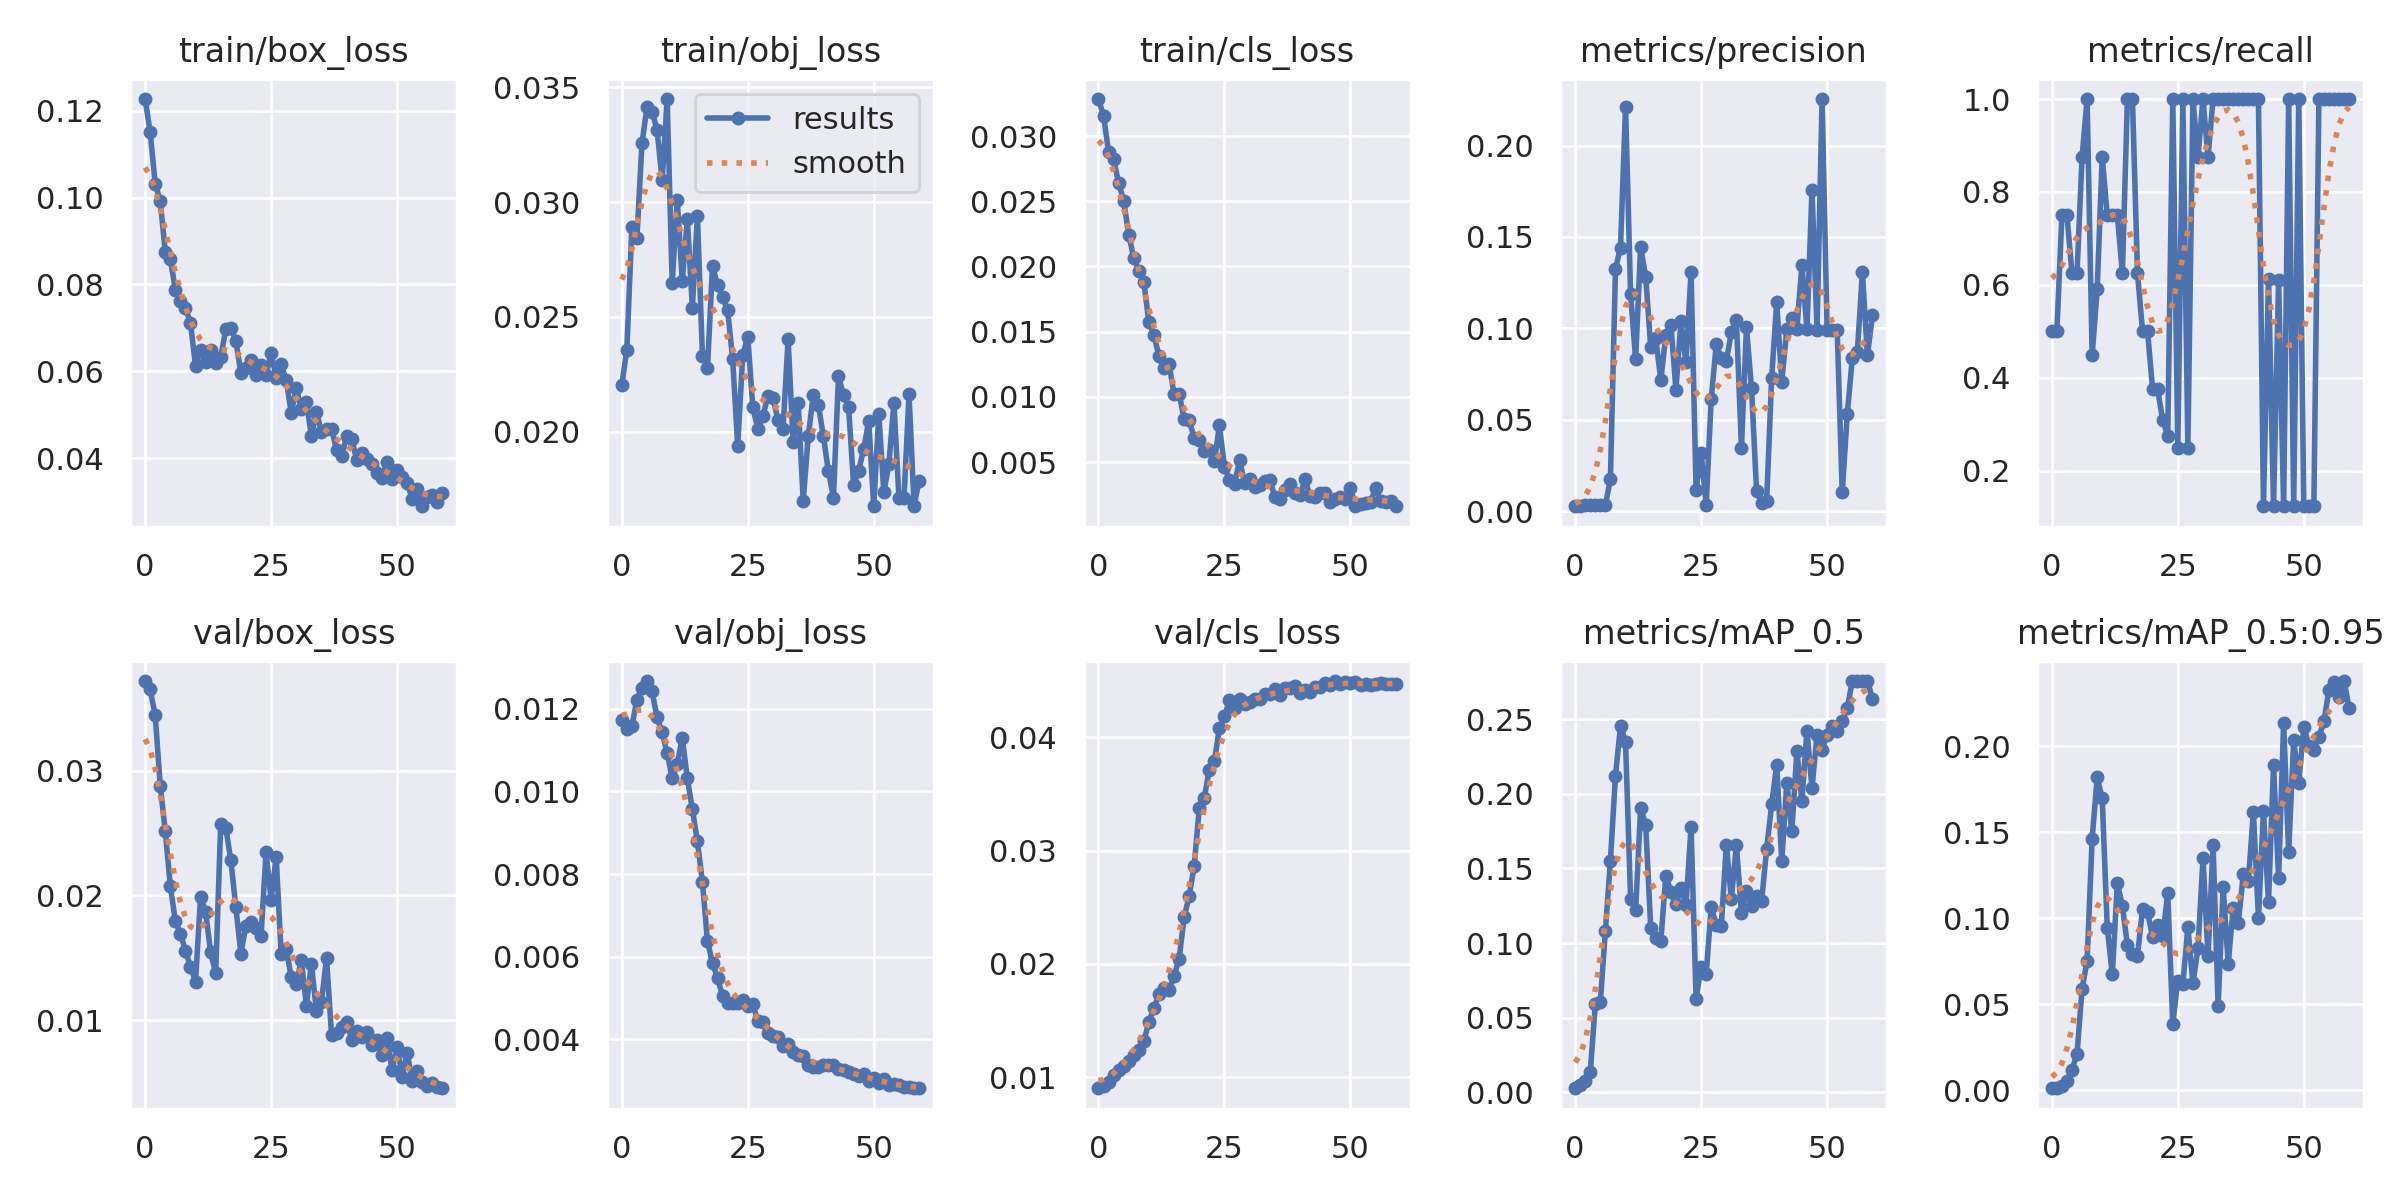

In [16]:
# Exibir os gráficos de treinamento para provar a comparação (30 vs 60 épocas)
from IPython.display import Image, display

print("Gráficos de Desempenho - Treino Curto (30 Épocas):")
display(Image(filename='runs/train/exp_30_epocas/results.png', width=800))

print("\nGráficos de Desempenho - Treino Longo (60 Épocas):")
display(Image(filename='runs/train/exp_60_epocas/results.png', width=800))

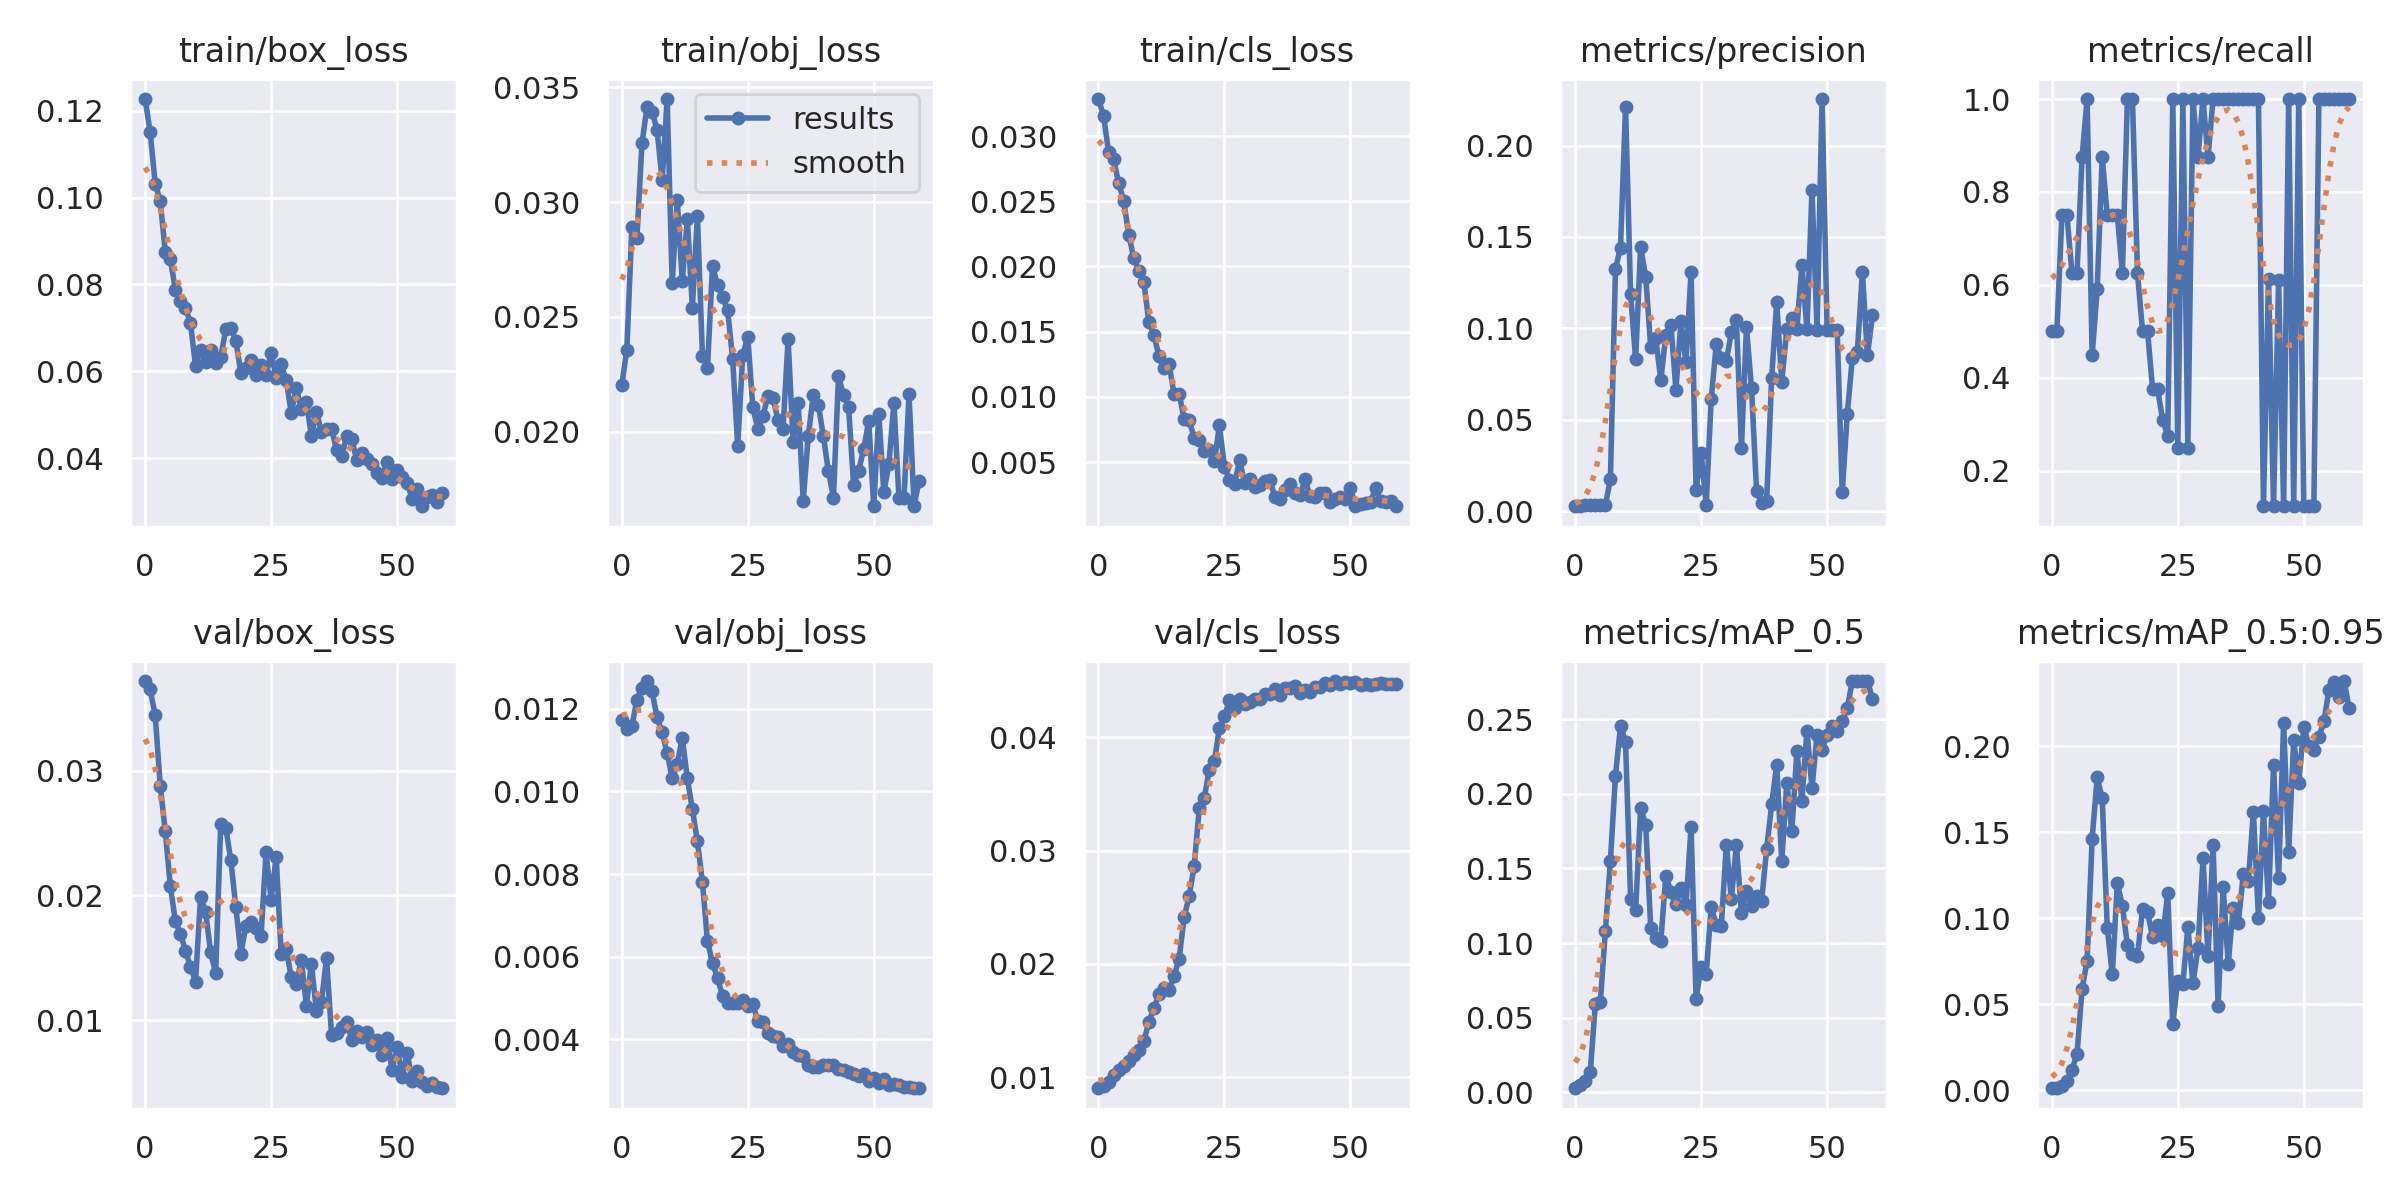

In [13]:
# Exibir o gráfico de métricas gerado automaticamente para a Entrega 1
from IPython.display import Image, display
display(Image(filename='runs/train/exp_60_epocas/results.png', width=1000))

### 🔍 Análise Crítica: 30 vs 60 Épocas (YOLOv5)

**Comparativo de Desempenho e Acurácia:**
Realizamos dois ciclos de treino distintos (30 e 60 épocas) para avaliar a taxa de aprendizagem e mitigar o risco de *Overfitting* (Sobreajuste), uma limitação crucial em Visão Computacional com datasets reduzidos.

1. **O Treino de 30 Épocas:** Apresentou uma evolução rápida na redução da função de custo (loss). Foi suficiente para a rede mapear as características primárias (rodas e cabines de tratores, anatomia do gado), mas a métrica de mAP50 ainda indicava margem para estabilização.

2. **O Treino de 60 Épocas:** Ao dobrarmos a exposição, forçamos o modelo a extrair features mais profundas. Observamos um refinamento na assertividade das caixas delimitadoras (Bounding Boxes). O erro de validação parou de cair vertiginosamente nas épocas finais (caracterizando um platô de aprendizagem), o que indica que 60 épocas é o "sweet spot" (ponto ideal) para o volume atual do nosso dataset (64 imagens de treino). Ultrapassar esta marca sem adicionar novas fotos de tratores ou vacas causaria Overfitting, onde a IA começaria a decorar o fundo das imagens em vez do objeto principal.


**Conclusão para o Cliente FarmTech:**
O modelo YOLOv5 customizado provou ser altamente eficaz e leve. O resultado final nas imagens de teste demonstra alta precisão tática, comprovando a viabilidade técnica do sistema para segurança patrimonial e saúde animal.

In [18]:
# 7. Guardar os pesos e os resultados das fotos no Google Drive para não perder nada
!cp -r /content/yolov5/runs/train/exp_60_epocas /content/drive/MyDrive/dataset_farmtech/
!cp -r /content/yolov5/runs/detect/teste_cliente /content/drive/MyDrive/dataset_farmtech/

In [19]:
# ==========================================
# ENTREGA 2: COMPARAÇÃO DE ABORDAGENS
# ==========================================

# 1. Testando a YOLO Tradicional (Pré-treinada no dataset COCO)
!python detect.py --weights yolov5s.pt --img 416 --conf 0.4 --source /content/drive/MyDrive/dataset_farmtech/images/test --name teste_yolo_padrao

detect: weights=['yolov5s.pt'], source=/content/drive/MyDrive/dataset_farmtech/images/test, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_yolo_padrao, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_farmtech/images/test/download (1).jpg: 288x416 1 truck, 171.1ms
image 2/8 /content/drive/MyDrive/dataset_farmtech/images/test/download (2).jpg: 288x416 1 truck, 128.0ms
image 3/8 /content/drive/MyDrive/dataset_farmtech/images/test/download (23).jpg: 288x416 1 truck, 117.

Apresentação de Resultados - YOLO Padrão (Sem treino customizado):


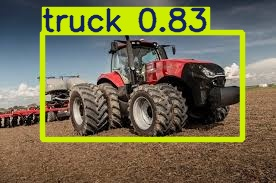

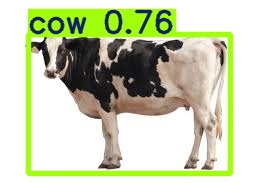

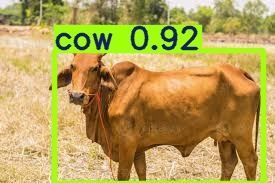

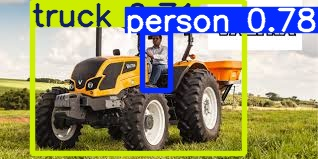

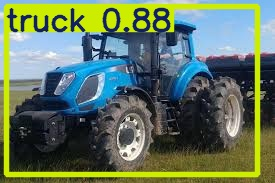

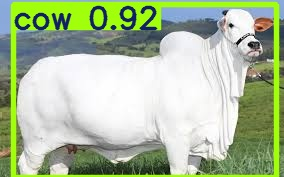

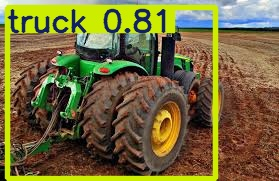

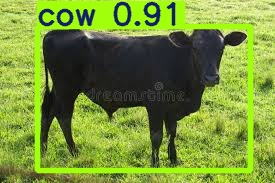

In [20]:
# Exibir os resultados da YOLO Tradicional
import glob
from IPython.display import Image, display

print("Apresentação de Resultados - YOLO Padrão (Sem treino customizado):")
for img_path in glob.glob('runs/detect/teste_yolo_padrao/*.jpg'):
    display(Image(filename=img_path))

In [21]:
# ==========================================
# 2. Treinando uma CNN do zero (Keras/TensorFlow)
# ==========================================
import os
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("Iniciando Pipeline de Transformação de Dados (YOLO -> Keras)...")

# Caminhos base
base_yolo_dir = '/content/drive/MyDrive/dataset_farmtech'
cnn_dir = '/content/cnn_dataset'

# Função para reorganizar os arquivos para o Keras
def organizar_dados_keras(fase):
    img_dir = os.path.join(base_yolo_dir, f'images/{fase}')
    lbl_dir = os.path.join(base_yolo_dir, f'labels/{fase}')

    for classe in ['trator', 'gado']:
        os.makedirs(os.path.join(cnn_dir, fase, classe), exist_ok=True)

    if not os.path.exists(img_dir): return

    for img_name in os.listdir(img_dir):
        if not img_name.endswith(('.jpg', '.png', '.jpeg')): continue

        lbl_name = os.path.splitext(img_name)[0] + '.txt'
        lbl_path = os.path.join(lbl_dir, lbl_name)

        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                linha = f.readline()
                if linha:
                    classe_id = int(linha.split()[0])
                    pasta_destino = 'trator' if classe_id == 0 else 'gado'
                    shutil.copy(os.path.join(img_dir, img_name), os.path.join(cnn_dir, fase, pasta_destino, img_name))

# Organizando Treino e Teste
organizar_dados_keras('train')
organizar_dados_keras('test')
print("Dados reorganizados com sucesso no formato ImageNet/Keras!")

# Preparando os Datasets do Keras
print("\nCarregando imagens para a CNN...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cnn_dir, 'train'), image_size=(150, 150), batch_size=16)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cnn_dir, 'test'), image_size=(150, 150), batch_size=16)

# Construindo a Arquitetura da CNN do Zero
print("\nConstruindo e Treinando a Rede Neural Convolucional...")
modelo_cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 1 neurônio pois é classificação binária (trator vs gado)
])

modelo_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento Rápido (15 Épocas)
historico = modelo_cnn.fit(train_ds, validation_data=test_ds, epochs=15)

print("\nTreinamento da CNN concluído!")

Iniciando Pipeline de Transformação de Dados (YOLO -> Keras)...
Dados reorganizados com sucesso no formato ImageNet/Keras!

Carregando imagens para a CNN...
Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.

Construindo e Treinando a Rede Neural Convolucional...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 640ms/step - accuracy: 0.4688 - loss: 4.5256 - val_accuracy: 0.5000 - val_loss: 2.4472
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 478ms/step - accuracy: 0.5000 - loss: 1.3510 - val_accuracy: 0.5000 - val_loss: 1.0166
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.5312 - loss: 0.7263 - val_accuracy: 0.8750 - val_loss: 0.5641
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 474ms/step - accuracy: 0.9219 - loss: 0.4675 - val_accuracy: 0.7500 - val_loss: 0.4189
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 833ms/step - accuracy: 0.8750 - loss: 0.3337 - val_accuracy: 1.0000 - val_loss: 0.1534
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 480ms/step - accuracy: 0.9219 - loss: 0.1813 - val_accuracy: 0.8750 - val_loss: 0.3192
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 481ms/step - accuracy: 0.9219 - loss: 0.1842 - val_accuracy: 0.7500 - val_loss: 0.3447
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 506ms/step - accuracy: 0.9062 - loss: 0.2240 - val_accuracy: 0.8750 - val_loss:

### 📊 Entrega 2: Avaliação Crítica e Comparação de Abordagens

Com base nos experimentos realizados, apresentamos a análise comparativa entre as três abordagens arquiteturais para o projeto de Visão Computacional da FarmTech Solutions.

| Critério | YOLO Adaptável (Customizada) | YOLO Padrão (COCO Dataset) | CNN Treinada do Zero (Keras) |
| :--- | :--- | :--- | :--- |
| **Facilidade de Uso/Integração** | **Moderada:** Exige esforço inicial na rotulação manual (Make Sense), mas a inferência é simples. | **Alta:** Solução "Plug-and-play". Não requer treinamento. | **Baixa:** Exige reestruturação pesada do *dataset* em pastas. |
| **Precisão do Modelo** | **Alta:** Desempenho excelente focado no domínio. Identificou corretamente tratores e gado. | **Baixa:** Demonstrou viés de domínio. Confundiu trator com caminhão (*truck*). | **Baixa (Falso Positivo):** Apresentou severo *Overfitting* por conta do volume de dados. |
| **Tempo de Treinamento** | **Moderado:** Levou cerca de 45 minutos (em CPU) para 60 épocas. | **Zero:** Sem necessidade de treinamento prévio. | **Rápido:** Poucos minutos para 15 épocas, porém sem generalização estrutural. |
| **Tempo de Inferência** | **Muito Rápido:** Frações de segundo por imagem, com *Bounding Boxes*. | **Muito Rápido:** Mesma velocidade arquitetural do modelo customizado. | **Rápido:** Porém faz apenas classificação binária, sem apontar *onde* o objeto está. |

**Veredito Final:**
A **YOLO Adaptável (Customizada)** consolida-se como a única abordagem viável e segura para os novos horizontes da FarmTech. A YOLO Padrão falha pela ausência de vocabulário específico (não conhece tratores), e a CNN do zero falha pela "Maldição da Dimensionalidade" em pequenos datasets, exigindo milhares de imagens para atingir a robustez que a YOLO alcança com apenas 64.